# 27 — `voronoi`

`Map.voronoi` turns scattered **points** into a tessellation: one cell per point, covering everywhere that point
is the nearest one. It answers the question a scatter plot cannot — *which site speaks for this ground?* — which
makes it the right first map for any network of fixed observation sites.

By the end of this notebook you will be able to build a Voronoi map from a point `FeatureCollection`, colour its
cells by an attribute, and trim them to a real boundary with `clip=`.

API: [`Map.voronoi`](../../reference/static_map.md).

> **Where this data comes from.** Everything in this notebook is real, downloaded with
> [earthlens](https://github.com/serapeum-org/earthlens) and committed under `examples/data/`.
> `examples/data/ATTRIBUTION.md` records each source and its licence.


**Setup** — inline figures, the data path, and the metric CRS this notebook works in.

In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
from pyramids.feature import FeatureCollection

from digitalearth.static import Map

# The notebook's own folder is the kernel's working directory, so the bundled
# example data sits three levels up: docs/examples/plots -> repo root.
DATA = Path("../../../examples/data")

# UTM zone 32N: a metric CRS, correct for south-west Germany. Distance-based
# renders (Voronoi, hex lattices, kernels) must not be computed in degrees.
UTM32 = 25832


## The data

3,000 bird occurrence records from **GBIF** for 2023, over the Heidelberg area — 111 species, each record a
dated observation at a coordinate.

In [2]:
birds = FeatureCollection.read_file(str(DATA / "heidelberg_birds_2023.geojson"))
print(f"{len(birds)} bird records, {birds['species'].nunique()} species, EPSG:{birds.crs.to_epsg()}")
birds[["species", "eventDate", "uncertainty_m"]].head()

3000 bird records, 111 species, EPSG:4326


,species,eventDate,uncertainty_m
0,Corvus corone,2023-01-11 12:27:25+00:00,NaN
1,Cyanistes caeruleus,2023-01-11 15:49:00+00:00,8.0
2,Phalacrocorax carbo,2023-01-11 11:58:48+00:00,NaN
3,Cyanistes caeruleus,2023-01-11 15:49:04+00:00,8.0
4,Alopochen aegyptiaca,2023-01-11 11:56:46+00:00,NaN


## From records to sites

Voronoi wants **sites**, not every record: 3,000 cells would be a grey smear. Birders return to the same places,
so rounding each record to a 0.01° cell and counting recovers the actual observation localities.

In [3]:
import geopandas as gpd
from shapely.geometry import Point

cell = birds.geometry.apply(lambda p: (round(p.x, 2), round(p.y, 2)))
sites = (birds.assign(cell=cell).groupby("cell")
         .agg(records=("key", "size"), species=("species", "nunique")).reset_index())
sites = sites[sites["records"] >= 5]

In [4]:
sites = FeatureCollection(gpd.GeoDataFrame(
    sites, geometry=[Point(x, y) for x, y in sites["cell"]], crs=birds.crs
).drop(columns="cell"))
print(f"{len(sites)} localities with 5+ records; counts run "
      f"{sites['records'].min()}-{sites['records'].max()}")
sites.sort_values("records", ascending=False).head(5)[["records", "species"]]

101 localities with 5+ records; counts run 5-304


,records,species
122,304,41
107,272,42
105,250,44
110,221,43
134,143,38


101 localities, the busiest with 304 records. That long tail is the real structure of volunteer recording — a few
heavily-watched sites and many visited once or twice.

## Quickstart — the bare tessellation

The minimal call takes just the points. One colour, so the map shows *geometry only*: how much ground each
locality is the nearest site for.

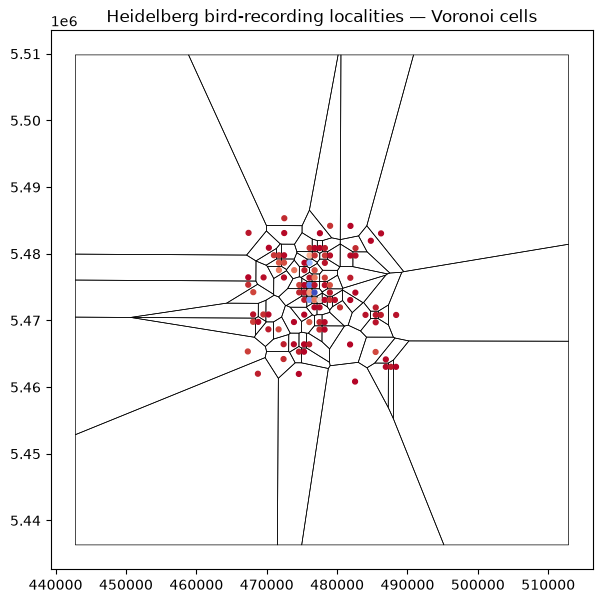

In [5]:
m = Map(crs=UTM32, figsize=(7, 7))
m.voronoi(sites)
m.points(sites, size=12)
m.set_title("Heidelberg bird-recording localities — Voronoi cells")
m.fig;

Read the cell sizes, not the colours. Small cells cluster where localities are packed together — the city and
the river corridor. The big cells on the rim are isolated sites standing in for several kilometres of ground, and
a big cell is a warning: whatever it is coloured by, one site is speaking for a lot of landscape.

## Colouring by a value

`column=` colours each cell by its own site's attribute, which makes the map a readable *nearest-neighbour
interpolation*: every location takes the value of the site nearest to it.

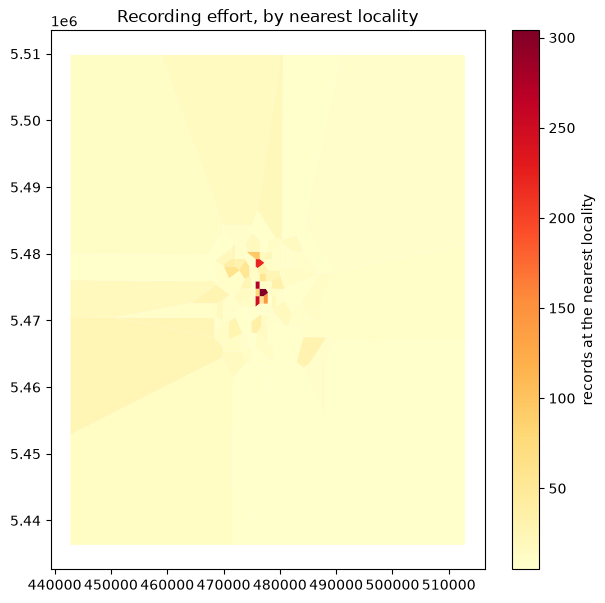

In [6]:
m = Map(crs=UTM32, figsize=(7, 7))
m.voronoi(sites, column="records", cmap="YlOrRd")
m.colorbar(label="records at the nearest locality")
m.set_title("Recording effort, by nearest locality")
m.fig;

This is a map of **effort**, not of birds. The hot cells are where people watch most, and the hard edges are
honest — the method claims nothing between sites, unlike a smooth surface that would invent a gradient. Mistaking
one for the other is the classic error with volunteer-collected data.

## Trimming to a boundary with `clip=`

Unclipped, the outer cells run to the edge of the figure — they are unbounded in principle. `clip=` intersects
every cell with a polygon layer, so the map stops where the study area does.

| argument | meaning | typical value |
|---|---|---|
| `features` | the point collection to tessellate | a point `FeatureCollection` |
| `column` | attribute to colour cells by | `None` (one colour) or a column name |
| `clip` | polygons to intersect the cells with | a polygon `FeatureCollection` |

In [7]:
states = FeatureCollection.read_file(str(DATA / "germany_adm1.geojson"))
bw = FeatureCollection(states[states["shapeName"] == "Baden-Württemberg"])
print("clipping to:", bw["shapeName"].iloc[0])

clipping to: Baden-Württemberg


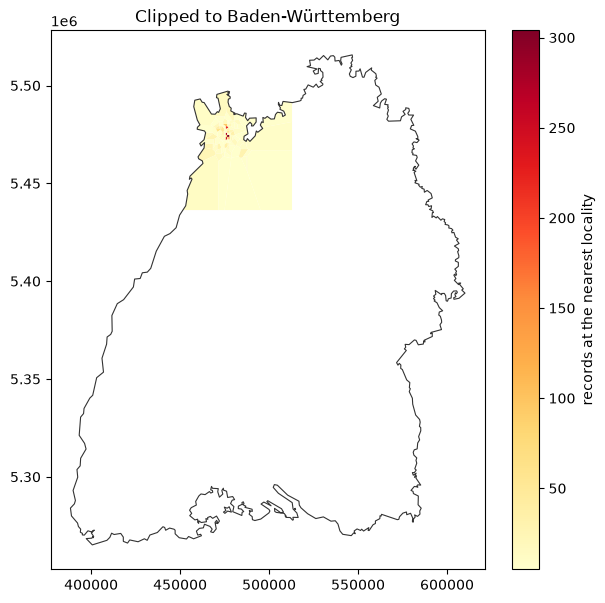

In [8]:
m = Map(crs=UTM32, figsize=(7, 7))
m.voronoi(sites, column="records", cmap="YlOrRd", clip=bw)
m.polygons(bw, edgecolor="#333333", linewidth=0.8)
m.colorbar(label="records at the nearest locality")
m.set_title("Clipped to Baden-Württemberg")
m.fig;

Clipping does two things at once: it removes the meaningless unbounded cells, and it exposes the extent of the
data. The cells now stop at the state line, and the empty ground beyond the cluster is visible as absence rather
than being papered over by a cell stretched across it.

## Takeaway

- `voronoi(points)` shows **coverage**: how much ground each site is the nearest for.
- `voronoi(points, column=...)` shows **nearest-neighbour values**, with no invented smoothness.
- `clip=` bounds the cells to a study area and makes the gaps legible.
- Aggregate records to sites first, and build it in a metric CRS — distances in degrees distort every cell.

Next: [`28_quadtree`](28_quadtree.ipynb) aggregates the raw records into adaptive cells instead.